# Ames Housing Price Prediction

## Project
**Objective:** The goal of this project is to predict the sale price of residential properties in Ames, Iowa, using the well-known Ames Housing Dataset. 

**Challenges:** 
1. **High Dimensionality:** Over 80 features.
2. **Data Quality:** The dataset contains missing values and outliers.
3. **Non-Linearity:** Real estate pricing often follows non-linear patterns and many features are highly skewd.
 
**Workflow:** 
EDA -> Preprocessing -> Modeling -> Evaluation


In [29]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.linear_model import Ridge, LinearRegression, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

from sklearn import set_config
set_config(transform_output="pandas")

## 1. Data Loading & Initial Cleaning

In [30]:
house_df = pd.read_csv('AmesHousing.csv')

house_df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [31]:
# Cleaning column names
house_df.columns = house_df.columns.str.replace(' ', '')
house_df.rename(columns={'YearRemod/Add': 'YearRemodAdd'}, inplace=True)

In [32]:
# Split Data
train, test = train_test_split(house_df, test_size=0.2, random_state=42)

trainX = train.drop(columns = ["SalePrice"])
trainY = np.log1p(train["SalePrice"]) # Log-transforming target for better normality

testX = test.drop(columns = ["SalePrice"])
testY = np.log1p(test["SalePrice"])

In [33]:
# Create a working copy for exploration
df = trainX.copy()

## 2. Exploratory Data Analysis

In [34]:
# Dataset Shape
r, c = df.shape
print(f"Dataset contains:\nRows: {r}\nColumns: {c}")

Dataset contains:
Rows: 2344
Columns: 81


### Profiling the Data
Create a metadata table to see exactly what I'm dealing.


In [35]:
profile = pd.DataFrame(index=df.columns)
profile["dtype"] = df.dtypes
profile["missing_count"] = df.isna().sum()
profile["missing_count_pct"] = df.isna().mean() * 100
profile["nunique"] = df.nunique()
profile["unique_ratio"] = df.nunique() / len(df)
profile["skew"] = df.select_dtypes(include="number").skew()

# Merge with descriptive stats
profile = profile.join(df.describe(include="all").T)
profile.drop(columns="unique", inplace=True, errors='ignore')
profile.head(10)

,dtype,missing_count,missing_count_pct,nunique,unique_ratio,skew,count,top,freq,mean,std,min,25%,50%,75%,max
Order,int64,0,0.000000,2344,1.000000,0.002033,2344.0,NaN,NaN,1464.298635,842.982263,1.0,737.75,1466.0,2195.25,2930.0
PID,int64,0,0.000000,2344,1.000000,0.057310,2344.0,NaN,NaN,714363167.521331,188690676.946579,526301100.0,528482070.0,535454060.0,907192052.5,924152030.0
MSSubClass,int64,0,0.000000,16,0.006826,1.364770,2344.0,NaN,NaN,57.30802,42.802555,20.0,20.0,50.0,70.0,190.0
MSZoning,str,0,0.000000,7,0.002986,NaN,2344,RL,1818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotFrontage,float64,393,16.766212,120,0.051195,1.735006,1951.0,NaN,NaN,69.207586,23.418018,21.0,58.0,68.0,80.0,313.0
LotArea,int64,0,0.000000,1634,0.697099,13.743796,2344.0,NaN,NaN,10127.857509,8050.908132,1300.0,7466.5,9356.5,11484.25,215245.0
Street,str,0,0.000000,2,0.000853,NaN,2344,Pave,2333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alley,str,2182,93.088737,2,0.000853,NaN,162,Grvl,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LotShape,str,0,0.000000,4,0.001706,NaN,2344,Reg,1496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LandContour,str,0,0.000000,4,0.001706,NaN,2344,Lvl,2109,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
# Numerical Columns Check
profile[
    profile["dtype"].isin([np.dtype("int64"), np.dtype("float64")])]

,dtype,missing_count,missing_count_pct,nunique,unique_ratio,skew,count,top,freq,mean,std,min,25%,50%,75%,max
Order,int64,0,0.000000,2344,1.000000,0.002033,2344.0,NaN,NaN,1464.298635,842.982263,1.0,737.75,1466.0,2195.25,2930.0
PID,int64,0,0.000000,2344,1.000000,0.057310,2344.0,NaN,NaN,714363167.521331,188690676.946579,526301100.0,528482070.0,535454060.0,907192052.5,924152030.0
MSSubClass,int64,0,0.000000,16,0.006826,1.364770,2344.0,NaN,NaN,57.30802,42.802555,20.0,20.0,50.0,70.0,190.0
LotFrontage,float64,393,16.766212,120,0.051195,1.735006,1951.0,NaN,NaN,69.207586,23.418018,21.0,58.0,68.0,80.0,313.0
LotArea,int64,0,0.000000,1634,0.697099,13.743796,2344.0,NaN,NaN,10127.857509,8050.908132,1300.0,7466.5,9356.5,11484.25,215245.0
OverallQual,int64,0,0.000000,10,0.004266,0.204464,2344.0,NaN,NaN,6.06442,1.38852,1.0,5.0,6.0,7.0,10.0
OverallCond,int64,0,0.000000,9,0.003840,0.595367,2344.0,NaN,NaN,5.581911,1.105659,1.0,5.0,5.0,6.0,9.0
YearBuilt,int64,0,0.000000,118,0.050341,-0.594285,2344.0,NaN,NaN,1970.506826,30.341434,1872.0,1953.0,1972.0,2000.0,2010.0
YearRemodAdd,int64,0,0.000000,61,0.026024,-0.428230,2344.0,NaN,NaN,1983.923635,20.786287,1950.0,1965.0,1992.0,2003.0,2010.0
MasVnrArea,float64,19,0.810580,391,0.166809,2.497916,2325.0,NaN,NaN,98.539785,172.239113,0.0,0.0,0.0,160.0,1290.0


Features "MSSubClass", "OverallQual", "OverallCond" are Categorical.    
"MSSubClass" is nominal and the rest ordinal.

No impossible values

In [37]:
# Categorical Columns Check
for col in df.columns:
    if profile.loc[col]["dtype"] == "str":
        print("\n")
        print(df[col].value_counts(dropna = False))



MSZoning
RL         1818
RM          371
FV          106
RH           24
C (all)      22
A (agr)       2
I (all)       1
Name: count, dtype: int64


Street
Pave    2333
Grvl      11
Name: count, dtype: int64


Alley
NaN     2182
Grvl     100
Pave      62
Name: count, dtype: int64


LotShape
Reg    1496
IR1     782
IR2      53
IR3      13
Name: count, dtype: int64


LandContour
Lvl    2109
HLS      97
Bnk      89
Low      49
Name: count, dtype: int64


Utilities
AllPub    2341
NoSewr       2
NoSeWa       1
Name: count, dtype: int64


LotConfig
Inside     1716
Corner      420
CulDSac     137
FR2          60
FR3          11
Name: count, dtype: int64


LandSlope
Gtl    2228
Mod     102
Sev      14
Name: count, dtype: int64


Neighborhood
NAmes      367
CollgCr    211
OldTown    199
Edwards    150
Gilbert    138
Somerst    136
NridgHt    121
Sawyer     119
NWAmes     109
SawyerW     98
Mitchel     97
Crawfor     89
BrkSide     84
IDOTRR      73
Timber      59
NoRidge     57
SWISU       37

Feature Categories ok. No typos/repeated categories.

### Identifying Problematic Features
Flag columns that might need dropping or special handling.


In [38]:
profile["high_missing"] = profile["missing_count_pct"] > 0 
profile["id_like"] = profile["unique_ratio"] > 0.95 
profile["constant"] = profile["nunique"] <= 1
profile["high_skew"] = profile["skew"].abs() > 1

In [39]:
# Check ID-like features 
print("ID-like features found:", profile.index[profile["id_like"]].tolist())

ID-like features found: ['Order', 'PID']


Drop 'Order' & 'PID

In [40]:
# Exploring Missing Value handling
profile.loc[profile["high_missing"] == True]

,dtype,missing_count,missing_count_pct,nunique,unique_ratio,skew,count,top,freq,mean,std,min,25%,50%,75%,max,high_missing,id_like,constant,high_skew
LotFrontage,float64,393,16.766212,120,0.051195,1.735006,1951.0,NaN,NaN,69.207586,23.418018,21.0,58.0,68.0,80.0,313.0,True,False,False,True
Alley,str,2182,93.088737,2,0.000853,NaN,162,Grvl,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,False
MasVnrType,str,1426,60.836177,4,0.001706,NaN,918,BrkFace,714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,False
MasVnrArea,float64,19,0.810580,391,0.166809,2.497916,2325.0,NaN,NaN,98.539785,172.239113,0.0,0.0,0.0,160.0,1290.0,True,False,False,True
BsmtQual,str,61,2.602389,5,0.002133,NaN,2283,TA,1057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,False
BsmtCond,str,61,2.602389,5,0.002133,NaN,2283,TA,2102,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,False
BsmtExposure,str,63,2.687713,4,0.001706,NaN,2281,No,1541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,False
BsmtFinType1,str,61,2.602389,6,0.002560,NaN,2283,Unf,677,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,False
BsmtFinSF1,float64,1,0.042662,882,0.376280,1.529633,2343.0,NaN,NaN,442.53137,452.223224,0.0,0.0,375.0,734.0,5644.0,True,False,False,True
BsmtFinType2,str,62,2.645051,6,0.002560,NaN,2282,Unf,1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False,False


Missing values at most cases means 'Feature doesnt exist in the house' (eg. Garage).    
'LotFrontage' need extra investigation.

### Investigation: Lot Frontage
Is LotFrontage missing at random? Let's check if it varies by neighborhood.

In [41]:
frontage_check = df.groupby("Neighborhood")["LotFrontage"].agg(["median", "mean", "std"])
print(frontage_check.head())

              median       mean        std
Neighborhood                              
Blmngtn         43.0  47.105263   4.965377
Blueste         24.0  25.571429   4.157609
BrDale          21.0  21.625000   1.244553
BrkSide         52.0  56.671233  14.260527
ClearCr         80.5  90.375000  24.749074


The median varies significantly by neighborhood.        
Impute LotFrontage using Neighborhood median rather than a global mean.


### Investigation: Basement Consistency


In [42]:
bsmt_cols = ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]
for col in bsmt_cols:
    print(f"{col}: {len(df.loc[df[col].isna()])}")

df[bsmt_cols].loc[df["BsmtQual"].isna()]

BsmtQual: 61
BsmtCond: 61
BsmtExposure: 63
BsmtFinType1: 61
BsmtFinType2: 62


,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2
1898,NaN,NaN,NaN,NaN,NaN
678,NaN,NaN,NaN,NaN,NaN
2702,NaN,NaN,NaN,NaN,NaN
649,NaN,NaN,NaN,NaN,NaN
952,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
206,NaN,NaN,NaN,NaN,NaN
2088,NaN,NaN,NaN,NaN,NaN
2278,NaN,NaN,NaN,NaN,NaN
1500,NaN,NaN,NaN,NaN,NaN


Most basement features are missing together, implying the house simply has no basement.


### Investigation: Outliers


In [43]:
summary = []
for col in df.select_dtypes(include="number").columns:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    summary.append({"feature": col, "outlier_count": len(outliers), "skew": df[col].skew()})

summary_df = pd.DataFrame(summary).sort_values("outlier_count", ascending=False)
summary_df.head(10)

,feature,outlier_count,skew
31,EnclosedPorch,388,3.993799
11,BsmtFinSF2,285,4.185302
33,ScreenPorch,205,3.894896
6,OverallCond,196,0.595367
2,MSSubClass,168,1.364770
9,MasVnrArea,158,2.497916
3,LotFrontage,144,1.735006
19,BsmtHalfBath,136,4.003080
30,OpenPorchSF,124,2.664539
4,LotArea,113,13.743796


Data has a lot of outliers but part of it is that features ar just absent from many houses.
Also, features like 'LotArea' are inheritly skewed, making them have outliers.
For now i'll use LogTransform to midigate the effect on the models.

## 3. Feature Engineering & Pipeline Construction


In [44]:
# Grouping columns for the Pipeline
none_cols = ["Alley", "MasVnrType", "FireplaceQu", "BsmtQual", "BsmtCond", "BsmtExposure", 
             "BsmtFinType1", "BsmtFinType2", "GarageType", "GarageFinish", "GarageQual", 
             "GarageCond", "PoolQC", "Fence", "MiscFeature"]

zero_cols = ["MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
             "1stFlrSF", "2ndFlrSF", "LowQualFinSF", "Fireplaces", "BsmtFullBath", 
             "BsmtHalfBath", "FullBath", "HalfBath", "GarageCars", "GarageArea",
             "WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch",
             "ScreenPorch", "PoolArea", "MiscVal"]

mode_cols = ["MoSold", "MSZoning", "Street", "LandContour", "LotConfig", "Neighborhood",
             "Condition1", "Condition2", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl",
             "Exterior1st", "Exterior2nd", "Foundation", "Heating", "CentralAir",
             "Functional", "PavedDrive", "SaleType", "SaleCondition", "MSSubClass", 
             "LotShape", "Utilities", "LandSlope", "Electrical", "ExterQual", "ExterCond", 
             "HeatingQC", "KitchenQual", "OverallQual", "OverallCond"]

median_cols = ["LotArea", "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd", "GrLivArea"]

### Custom Transformers

In [45]:
class NeighborhoodMedianImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.medians_ = X.groupby("Neighborhood")["LotFrontage"].median()
        self.global_median_ = X["LotFrontage"].median()
        return self
    def transform(self, X):
        X = X.copy()
        X["LotFrontage"] = X["LotFrontage"].fillna(X["Neighborhood"].map(self.medians_))
        X["LotFrontage"] = X["LotFrontage"].fillna(self.global_median_)
        return X

class YearBuiltImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = X.copy()
        X["YearRemodAdd"] = X["YearRemodAdd"].fillna(X["YearBuilt"])
        X["GarageYrBlt"] = X["GarageYrBlt"].fillna(X["YearBuilt"])
        return X

class AgeFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = X.copy()
        X["HouseAge"] = X["YrSold"] - X["YearBuilt"]
        X["RemodelAge"] = X["YrSold"] - X["YearRemodAdd"]
        X["GarageAge"] = X["YrSold"] - X["GarageYrBlt"]
        return X

class SkewLogTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=1): self.threshold = threshold
    def fit(self, X, y=None):
        num_cols = X.select_dtypes(include="number").columns
        skewness = X[num_cols].skew()
        self.skewed_cols = skewness[skewness.abs() > self.threshold].index.tolist()
        return self
    def transform(self, X):
        X = X.copy()
        X[self.skewed_cols] = np.log1p(X[self.skewed_cols])
        return X

## 4. Training and Evaluation
I will now run a comparison across multiple models. 

In [46]:
# Numerical Column
num_cols = ["LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1",
            "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", 
            "2ndFlrSF", "LowQualFinSF", "GrLivArea", "BsmtFullBath", 
            "BsmtHalfBath", "FullBath", "HalfBath", "BedroomAbvGr", 
            "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces", "GarageCars",
            "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch", 
            "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal",
            "HouseAge", "RemodelAge", "GarageAge"]

# One Hot Encode
nominal_cols = ["MSZoning", "Alley", "LandContour", 
                "LotConfig", "Neighborhood", "Condition1", "Condition2", 
                  "BldgType", "HouseStyle", "RoofStyle", "RoofMatl",
                  "Exterior1st", "Exterior2nd", "MasVnrType", "Foundation", 
                  "Heating", "Functional", "GarageType", 
                  "GarageFinish", "PavedDrive", "MiscFeature", "SaleType", 
                  "SaleCondition", "MSSubClass"]

# Ordinal Encode
ordinal_cols = ["LotShape", "Utilities", "LandSlope", "ExterQual", 
                "ExterCond", "BsmtQual", "BsmtCond", "BsmtExposure", 
                  "BsmtFinType1", "BsmtFinType2", "HeatingQC", "Electrical", 
                  "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", 
                  "PoolQC", "Fence", "OverallQual", "OverallCond"]

ordinal_mappings = {
            "LotShape": {"IR3": 1, "IR2": 2, "IR1": 3, "Reg": 4},
            "Utilities": {"ELO": 1, "NoSeWa": 2, "NoSewr": 3, "AllPub": 4},
            "LandSlope": {"Sev": 1, "Mod": 2, "Gtl": 3},
            "ExterQual": {"Po": 1, "Fa": 2, "Gd":3, "Ex": 4},
            "ExterCond": {"Po": 1, "Fa": 2, "Gd":3, "Ex": 4},
            "BsmtQual": {"None": 1, "Po": 2, "Fa": 3, "Gd":4, "Ex": 5},
            "BsmtCond": {"None": 1, "Po": 2, "Fa": 3, "Gd":4, "Ex": 5},
            "BsmtExposure": {"None": 1, "No":2, "Mn":3, "Av":4, "Gd": 5},
            "BsmtFinType1": {"None": 1, "Unf": 2, "LwQ": 3, "Rec": 4, "BLQ": 5, "ALQ": 6, "GLQ": 7},
            "BsmtFinType2": {"None": 1, "Unf": 2, "LwQ": 3, "Rec": 4, "BLQ": 5, "ALQ": 6, "GLQ": 7},
            "HeatingQC": {"Po": 1, "Fa": 2, "Gd":3, "Ex": 4},
            "Electrical": {"Mix": 1, "FuseP": 2, "FuseF": 3, "FuseA": 4, "SBrkr": 5},
            "KitchenQual": {"Po": 1, "Fa": 2, "Gd":3, "Ex": 4},
            "FireplaceQu": {"None": 1, "Po": 2, "Fa": 3, "TA": 4, "Gd":5, "Ex": 6},
            "GarageQual": {"None": 1, "Po": 2, "Fa": 3, "TA": 4, "Gd":5, "Ex": 6},
            "GarageCond": {"None": 1, "Po": 2, "Fa": 3, "TA": 4, "Gd":5, "Ex": 6},
            "PoolQC": {"None": 1, "Fa": 2, "TA": 3, "Gd":4, "Ex": 5},
            "Fence": {"None": 1, "MnWw": 2, "GdWo": 3, "MnPr": 4, "GdPr": 5}, 		
            "OverallQual": {1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10},
            "OverallCond": {1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10}
            }

class OrdinalMapper(BaseEstimator, TransformerMixin):

    def __init__(self, mappings):
        self.mappings = mappings

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        for col, mapping in self.mappings.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
            
            X[col] = X[col].fillna(-1)

        return X

In [47]:
# Define Encoding and Scaling
num_cols_final = median_cols + zero_cols + ["LotFrontage", "HouseAge", "RemodelAge", "GarageAge"]
nominal_cols = ["MSZoning", "Neighborhood", "Foundation", "GarageType", "SaleType", "SaleCondition"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), nominal_cols),
        ("ord", OrdinalMapper(mappings=ordinal_mappings), ordinal_cols)        
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [48]:
models = {
    "Ridge": Ridge(alpha=10.0),
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(alpha=1, max_iter = 10000),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoost": GradientBoostingRegressor(n_estimators=1000, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=42),
    "NeuralNetwork": MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=1000, random_state=42)
}

results = []

for name, model in models.items():
    # Constructing the full pipeline
    full_pipeline = Pipeline([
        ("lotfrontage_imp", NeighborhoodMedianImputer()),
        ("yrbuilt_imp", YearBuiltImputer()),
        ("impute_others", ColumnTransformer([
            ("none", SimpleImputer(strategy="constant", fill_value="None"), none_cols),
            ("zero", SimpleImputer(strategy="constant", fill_value=0), zero_cols),
            ("mode", SimpleImputer(strategy="most_frequent"), mode_cols),
            ("median", SimpleImputer(strategy="median"), median_cols)
        ], remainder="passthrough", verbose_feature_names_out=False)),
        ("age_eng", AgeFeatureEngineer()),
        ("log_skew", SkewLogTransformer(threshold=1)),
        ("preprocess", preprocessor),
        ("regressor", model)
    ])
    
    full_pipeline.fit(trainX, trainY)
    preds = full_pipeline.predict(testX)
    
    # Metrics
    mae = mean_absolute_error(testY, preds)
    rmse = root_mean_squared_error(testY, preds)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse})

## 5. Final Results & Observations

In [49]:
results_df = pd.DataFrame(results).sort_values("MAE")
print(results_df)

              Model       MAE      RMSE
6           XGBoost  0.073945  0.105320
5     GradientBoost  0.074862  0.111903
1  LinearRegression  0.080274  0.115732
0             Ridge  0.080407  0.116341
4      RandomForest  0.083884  0.121640
3        ElasticNet  0.088286  0.126377
7     NeuralNetwork  0.158118  0.225097
2             Lasso  0.339461  0.432582


### Summary of the Process:
1. **EDA:** Investigated basement features and LotFrontage. Decided on neighborhood-based imputation. Checked missing values, outliers and all features for impossible values or wrong inputs.
2. **Preprocessing:** Remove "id-like" columns(not use them during modeling). Impute LotArea with Neighborhood Median and also the rest of missing values(absent of features in house).
3. **Feature Engineering:** Create features like "HouseAge".
4. **Handling Skewness:** Rather than deleting outliers, I used a Log Transformation to allow the model to learn from them without being overwhelmed by their scale.
5. **Encoding:** 
5. **Model Performance:** 
    The best performing model was **XGBoost**, achieving a **MAE** of 0.0739 in log space, corresponding to approximately 7–8% average prediction error. Gradient boosting methods consistently outperformed other approaches, confirming their suitability for structured tabular regression tasks.

    Interestingly, linear models (Linear Regression and Ridge) performed nearly on par with boosting methods, suggesting that the feature engineering process effectively linearized much of the underlying signal in the dataset.

    In contrast, neural networks significantly underperformed, highlighting their limited effectiveness on small-scale tabular datasets. Lasso regression also performed poorly.

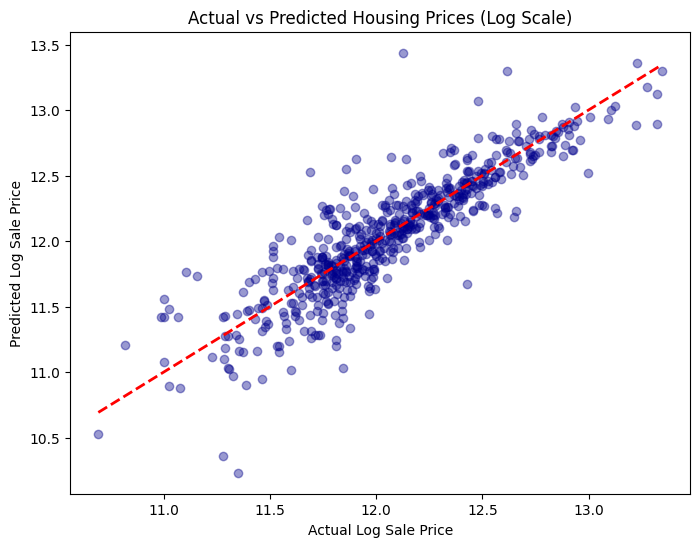

In [50]:
# Visualizing Neural Network predictions
plt.figure(figsize=(8, 6))
plt.scatter(testY, preds, alpha=0.4, color='darkblue')
plt.plot([testY.min(), testY.max()], [testY.min(), testY.max()], '--r', linewidth=2)
plt.title("Actual vs Predicted Housing Prices (Log Scale)")
plt.xlabel("Actual Log Sale Price")
plt.ylabel("Predicted Log Sale Price")
plt.show()